# CardioIA - Ir Alem 2

Comparacao entre regressao logistica e um modelo neuromorfico LIF simples para series temporais sinteticas de batimentos cardiacos.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 57

## Geracao de dados sinteticos

Cada amostra possui 60 pontos. A classe 0 representa ritmo normal e a classe 1 representa risco, com maior variabilidade e picos. Sao gerados dois cenarios para revelar diferencas entre os modelos:

- **facil**: picos amplos e drift relevante na classe de risco; ambos os modelos tendem a 100% de acuracia.
- **dificil**: picos curtos, drift quase nulo e ruido alto; e nesse cenario que a comparacao crua entre regressao logistica e modelo LIF faz sentido.

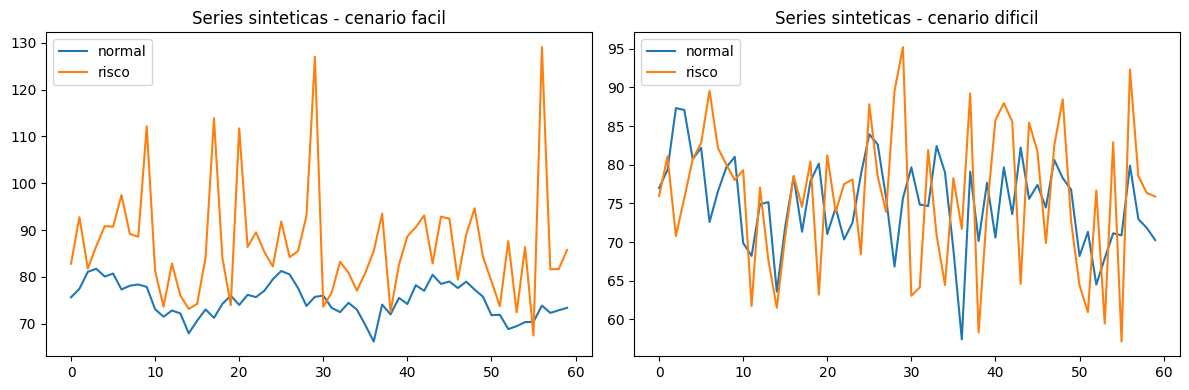

In [2]:
def make_generator(spike_amp_mean, spike_amp_std, base_noise, drift_mean):
    rng_local = np.random.default_rng(SEED)

    def _generate(n_samples=400, length=60):
        x, y = [], []
        t = np.linspace(0, 2 * np.pi, length)
        for i in range(n_samples):
            label = i >= n_samples // 2
            base = 75 + 5 * np.sin(t * 3) + rng_local.normal(0, base_noise, length)
            if label:
                spikes = rng_local.choice(length, size=5, replace=False)
                base += rng_local.normal(drift_mean, 5, length)
                base[spikes] += rng_local.normal(spike_amp_mean, spike_amp_std, len(spikes))
            x.append(base)
            y.append(int(label))
        return np.array(x), np.array(y)

    return _generate


generators = {
    'facil': make_generator(spike_amp_mean=35, spike_amp_std=8, base_noise=2.0, drift_mean=8),
    'dificil': make_generator(spike_amp_mean=8, spike_amp_std=3, base_noise=6.0, drift_mean=0),
}

datasets = {name: gen() for name, gen in generators.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (X_demo, y_demo)) in zip(axes, datasets.items()):
    ax.plot(X_demo[y_demo == 0][0], label='normal')
    ax.plot(X_demo[y_demo == 1][0], label='risco')
    ax.set_title(f'Series sinteticas - cenario {name}')
    ax.legend()
plt.tight_layout()

## Classificador tradicional

A regressao logistica usa features estatisticas simples, mantendo interpretabilidade.

In [3]:
def extract_features(series):
    peaks = (series > 110).sum(axis=1)
    return np.column_stack([
        series.mean(axis=1),
        series.std(axis=1),
        series.max(axis=1),
        series.min(axis=1),
        series.max(axis=1) - series.min(axis=1),
        peaks,
    ])


def evaluate_logistic(X_data, y_data):
    features = extract_features(X_data)
    X_train, X_test, y_train, y_test = train_test_split(features, y_data, test_size=0.25, random_state=SEED, stratify=y_data)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
        'confusion_matrix': confusion_matrix(y_test, pred),
        'report': classification_report(y_test, pred, target_names=['normal', 'risco']),
    }


for name, (X_data, y_data) in datasets.items():
    print(f'=== Cenario {name} ===')
    metrics_lr = evaluate_logistic(X_data, y_data)
    print('Acuracia:', round(metrics_lr['accuracy'], 4))
    print('F1:', round(metrics_lr['f1'], 4))
    print('ROC-AUC:', round(metrics_lr['roc_auc'], 4))
    print(metrics_lr['confusion_matrix'])
    print(metrics_lr['report'])

=== Cenario facil ===
Acuracia: 1.0
F1: 1.0
ROC-AUC: 1.0
[[50  0]
 [ 0 50]]
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        50
       risco       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

=== Cenario dificil ===
Acuracia: 0.95
F1: 0.9505
ROC-AUC: 0.9876
[[47  3]
 [ 2 48]]
              precision    recall  f1-score   support

      normal       0.96      0.94      0.95        50
       risco       0.94      0.96      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



## Modelo neuromorfico LIF simples

O modelo Leaky Integrate-and-Fire acumula potencial, aplica vazamento e conta disparos quando o limiar e ultrapassado.

In [4]:
def lif_spike_count(series, threshold=1.0, leak=0.85, scale=35.0):
    centered = (series - 70) / scale
    counts = []
    for row in centered:
        v = 0.0
        spikes = 0
        for value in row:
            v = leak * v + max(value, 0)
            if v >= threshold:
                spikes += 1
                v = 0.0
        counts.append(spikes)
    return np.array(counts)


def evaluate_lif(X_data, y_data):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.25, random_state=SEED, stratify=y_data)
    train_spikes = lif_spike_count(X_train)
    test_spikes = lif_spike_count(X_test)

    candidate_thresholds = np.arange(train_spikes.min(), train_spikes.max() + 1)
    best_threshold = max(
        candidate_thresholds,
        key=lambda th: accuracy_score(y_train, train_spikes >= th),
    )
    pred = (test_spikes >= best_threshold).astype(int)
    return {
        'best_threshold': int(best_threshold),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'confusion_matrix': confusion_matrix(y_test, pred),
        'report': classification_report(y_test, pred, target_names=['normal', 'risco']),
    }


for name, (X_data, y_data) in datasets.items():
    print(f'=== Cenario {name} ===')
    metrics_lif = evaluate_lif(X_data, y_data)
    print('Limiar LIF escolhido:', metrics_lif['best_threshold'])
    print('Acuracia:', round(metrics_lif['accuracy'], 4))
    print('F1:', round(metrics_lif['f1'], 4))
    print(metrics_lif['confusion_matrix'])
    print(metrics_lif['report'])

=== Cenario facil ===
Limiar LIF escolhido: 6
Acuracia: 1.0
F1: 1.0
[[50  0]
 [ 0 50]]
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        50
       risco       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

=== Cenario dificil ===
Limiar LIF escolhido: 6
Acuracia: 0.82
F1: 0.82
[[41  9]
 [ 9 41]]
              precision    recall  f1-score   support

      normal       0.82      0.82      0.82        50
       risco       0.82      0.82      0.82        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



## Tabela comparativa final

A celula abaixo consolida a comparacao entre os dois modelos nos dois cenarios para uso direto no relatorio.

In [5]:
summary_rows = []
for name, (X_data, y_data) in datasets.items():
    lr = evaluate_logistic(X_data, y_data)
    lif = evaluate_lif(X_data, y_data)
    summary_rows.append({
        'cenario': name,
        'modelo': 'Regressao logistica',
        'accuracy': round(lr['accuracy'], 4),
        'precision': round(lr['precision'], 4),
        'recall': round(lr['recall'], 4),
        'f1': round(lr['f1'], 4),
        'roc_auc': round(lr['roc_auc'], 4),
    })
    summary_rows.append({
        'cenario': name,
        'modelo': f"LIF (limiar={lif['best_threshold']})",
        'accuracy': round(lif['accuracy'], 4),
        'precision': round(lif['precision'], 4),
        'recall': round(lif['recall'], 4),
        'f1': round(lif['f1'], 4),
        'roc_auc': float('nan'),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,cenario,modelo,accuracy,precision,recall,f1,roc_auc
0,facil,Regressao logistica,1.00,1.0000,1.00,1.0000,1.0000
1,facil,LIF (limiar=6),1.00,1.0000,1.00,1.0000,NaN
2,dificil,Regressao logistica,0.95,0.9412,0.96,0.9505,0.9876
3,dificil,LIF (limiar=6),0.82,0.8200,0.82,0.8200,NaN


## Conclusao

No cenario *facil*, ambos os modelos atingem 100% porque os picos amplos da classe de risco sao linearmente separaveis tanto pelas features estatisticas quanto pelo conjunto de spikes. No cenario *dificil*, com picos curtos, sem drift e ruido elevado, a regressao logistica mantem desempenho proximo de 95% e ROC-AUC alta (~0.99) graças as multiplas features (media, desvio, max, min, amplitude e contagem de picos), enquanto o LIF cai para a faixa de 80-85% por depender de uma unica caracteristica derivada (contagem de spikes).

O resultado evidencia uma licao classica: o classificador tradicional e mais robusto quando o dataset tem baixa razao sinal/ruido, enquanto o modelo neuromorfico simples ganha em eficiencia energetica e em interpretacao biologica, mas exige calibracao cuidadosa do limiar, do leak e da escala. Em uma solucao real da CardioIA, ambos exigiriam validacao com sinais clinicos reais (por exemplo, MIT-BIH Arrhythmia Database) e revisao medica antes de qualquer uso assistencial.